# Waste generation prediction — data exploration

Dataset: World Bank *What a Waste* Global Database, city-level file.
Goal: understand the data well enough to pick a feature set for `00_basemodel.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 20)
df = pd.read_csv("../data/WhatAWaste_City_Level.csv")
df.shape

(367, 113)

## Target column

`total_msw_total_msw_generated_tons_year` reads in as text, not a number. One row has `"100,000"` with a thousands-separator comma, which forces the whole column to strings.

In [2]:
target = "total_msw_total_msw_generated_tons_year"
df[target] = df[target].astype(str).str.replace(",", "", regex=False)
df[target] = pd.to_numeric(df[target], errors="coerce")
df[target].describe()

count    3.260000e+02
mean     5.849429e+05
std      1.004828e+06
min      8.723500e+02
25%      5.392875e+04
50%      2.177520e+05
75%      5.470458e+05
max      7.903000e+06
Name: total_msw_total_msw_generated_tons_year, dtype: float64

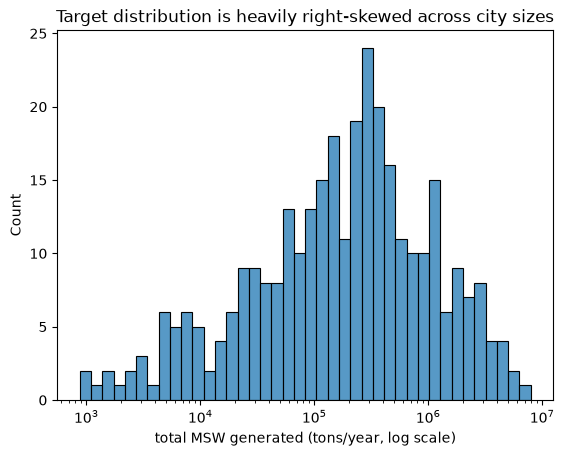

In [3]:
sns.histplot(df[target].dropna(), bins=40, log_scale=True)
plt.xlabel("total MSW generated (tons/year, log scale)")
plt.title("Target distribution is heavily right-skewed across city sizes")
plt.show()

## Missing data

The file has 113 columns but most are sparsely filled survey fields (fees, transfer stations, legal framework, etc). Keep only columns with low missingness as model features.

In [4]:
missing = df.isna().mean().sort_values()
missing[missing < 0.30]

iso3c                                      0.000000
region_id                                  0.000000
country_name                               0.000000
income_id                                  0.000000
city_name                                  0.000000
population_population_number_of_people     0.027248
total_msw_total_msw_generated_tons_year    0.111717
composition_food_organic_waste_percent     0.207084
composition_other_percent                  0.209809
composition_paper_cardboard_percent        0.209809
composition_plastic_percent                0.228883
composition_glass_percent                  0.267030
composition_metal_percent                  0.277929
dtype: float64

## Candidate features

Based on the missingness above, the usable feature set is:

- `population_population_number_of_people` — city population
- `income_id` — World Bank income group (categorical)
- `region_id` — World Bank region (categorical)
- `composition_food_organic_waste_percent`
- `composition_paper_cardboard_percent`
- `composition_plastic_percent`
- `composition_glass_percent`
- `composition_metal_percent`
- `composition_other_percent`

Everything else is missing in 50%+ of cities and isn't reliable enough to model on.

In [5]:
features = [
    "population_population_number_of_people",
    "income_id",
    "region_id",
    "composition_food_organic_waste_percent",
    "composition_paper_cardboard_percent",
    "composition_plastic_percent",
    "composition_glass_percent",
    "composition_metal_percent",
    "composition_other_percent",
]
df[features + [target]].describe(include="all")

,population_population_number_of_people,income_id,region_id,composition_food_organic_waste_percent,composition_paper_cardboard_percent,composition_plastic_percent,composition_glass_percent,composition_metal_percent,composition_other_percent,total_msw_total_msw_generated_tons_year
count,3.570000e+02,367,367,291.000000,290.000000,283.000000,269.000000,265.000000,290.000000,3.260000e+02
unique,NaN,4,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,LMC,ECS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,124,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.631290e+06,NaN,NaN,45.424727,12.685928,11.456355,4.058437,2.978308,20.308766,5.849429e+05
std,2.621100e+06,NaN,NaN,18.321482,8.490869,6.381125,3.959363,2.928135,15.151943,1.004828e+06
min,6.000000e+03,NaN,NaN,0.930000,0.080000,0.010000,0.000000,0.010000,0.500000,8.723500e+02
25%,1.930000e+05,NaN,NaN,34.200000,6.600000,7.020000,1.500000,1.000000,8.925000,5.392875e+04
50%,6.640460e+05,NaN,NaN,47.900000,11.040000,11.000000,3.000000,2.000000,17.000000,2.177520e+05
75%,1.798218e+06,NaN,NaN,57.350000,17.000000,15.000000,5.000000,4.000000,26.432500,5.470458e+05


In [6]:
numeric_features = [f for f in features if df[f].dtype != "object"]
corr = df[numeric_features + [target]].corr(numeric_only=True)[target].sort_values(ascending=False)
corr

total_msw_total_msw_generated_tons_year    1.000000
population_population_number_of_people     0.891969
composition_paper_cardboard_percent        0.134866
composition_plastic_percent                0.034210
composition_glass_percent                  0.033282
composition_food_organic_waste_percent    -0.012582
composition_other_percent                 -0.031664
composition_metal_percent                 -0.057369
Name: total_msw_total_msw_generated_tons_year, dtype: float64

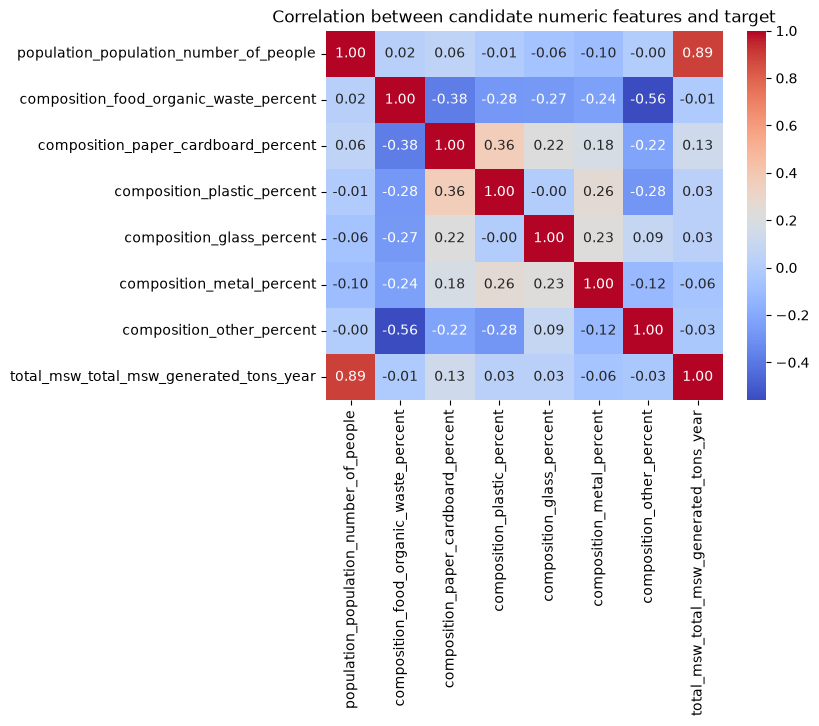

In [7]:
sns.heatmap(df[numeric_features + [target]].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between candidate numeric features and target")
plt.show()

## Conclusion

Population is, unsurprisingly, the strongest single predictor of total waste generated (bigger cities produce more waste in absolute terms). Composition shares add information about *what kind* of waste is being generated rather than *how much*, and income/region capture economic effects population alone won't.

Final feature set carried into `00_basemodel.ipynb`: the 9 columns above, target = `total_msw_total_msw_generated_tons_year` (cleaned), rows with missing target dropped.